In [ ]:
# import sys
# import numpy as np
# import matplotlib.pyplot as plt
# import pickle
# sys.path.append('../../map/')
# from map import *

# plotting the correct trajectory and map for a couple of instances of testing data

import sys
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
sys.path.insert(0, "/data/robert/CP-X-Prediction/Intersection-Code/Intersection-MTR/Prediction/MTR")
sys.path.append('../../map/')
from mtr.datasets.waymo.waymo_dataset import *
sys.path.append('../../map/')
from map import *

In [ ]:
with open('/data/robert/CP-X-Prediction/Intersection-Code/Intersection-MTR/Prediction/MTR/output/challenge/mtr-training-CPX-Prediction/default/eval/eval_with_train/epoch_25/result.pkl', 'rb') as file:
        test_results = pickle.load(file)

In [ ]:
# test_results is a list object
# dict_keys(['scenario_id', 'pred_trajs', 'pred_scores', 'object_id', 'object_type', 'gt_trajs', 'track_index_to_predict'])
# 441 - number of scenarios considered
# (6, 80, 2)
# there are 7 keys for the dictionary
# there are 6 multimodal paths
# there are 2 (x,y) coordinates at each timestep
# there are 2 agents being predicted per scene
output_test_results = "/data/robert/CP-X-Prediction/Intersection-Code/Intersection-MTR/Visualization/cpx_mtr_viz/test_results.txt"
with open(output_test_results, "w") as f:
    print(test_results[0][0], file=f)
    print(test_results[0][0].keys(), file=f)
    print(len(test_results), file=f)
    print(test_results[0][0]['pred_trajs'].shape, file=f)  # (6 modes, 80 timesteps, 2 coordinates)

In [4]:
print(f"Number of agents for the first scene: {len(test_results[0])}")
print(f"Number of dictionary keys: {len(test_results[0][0])}")
print(f"Shape of predicted trajs: {str(test_results[0][0]['pred_trajs'].shape)}")

Number of agents for the first scene: 2
Number of dictionary keys: 7
Shape of predicted trajs: (6, 80, 2)


In [5]:
# Check if the first agent and second agent in the batch are from the same scene
is_same_scene = test_results[0][0]['scenario_id'] == test_results[0][1]['scenario_id']
print(f"Are the first two agents from the same scene? {is_same_scene}")

Are the first two agents from the same scene? True


In [6]:
# basic plotting, only plot the traj
def plot_traj(sample_id, traj_id, data, mode):

    pred_traj = data[sample_id][traj_id]['pred_trajs']
    gt_traj = data[sample_id][traj_id]['gt_trajs']
    for i in range(mode):

        pred_traj_i = pred_traj[i]
        x_coords = pred_traj_i[:, 0]
        y_coords = pred_traj_i[:, 1]
        # print(x_coords.shape)
        x_coords = np.insert(x_coords, 0, gt_traj[10, 0])
        y_coords = np.insert(y_coords, 0, gt_traj[10, 1])
        

        plt.plot(x_coords, y_coords, marker='o', linestyle='-', color='red', markersize=1)

    plt.plot(gt_traj[:, 0], gt_traj[:, 1], marker='o', linestyle='-', color='blue', markersize=1)
    plt.plot(gt_traj[:11, 0], gt_traj[:11, 1], marker='o', linestyle='-', color='green', markersize=1)

    plt.plot(gt_traj[10][0], gt_traj[10][1], marker='*', color='yellow', markersize=5)

    plt.show()

In [7]:
# plot traj with map
def plot_traj_withmap(sample_id, traj_id, data, vector_map, mode):
    fig, ax = plt.subplots()
    fig.set_size_inches(20, 25)

    legend_added = {}

    for feature in vector_map.map_features:
        if isinstance(feature, Lane):
            if feature.type == LaneType.Sidewalk:
                label = "Sidewalk" if "Sidewalk" not in legend_added else ""
                ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k--',
                        linewidth=2, label=label)
                legend_added["Sidewalk"] = True
            elif feature.type == LaneType.Shoulder:
                #ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k--', 
                #       linewidth=2, label=f"shoulder-{feature.road_id}-{feature.lane_id}")
                continue
            else:
                label = "Lane" if "Lane" not in legend_added else ""
                ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k',
                        label=label)
                legend_added["Lane"] = True
        elif isinstance(feature, Crosswalk):
            label = "Crosswalk" if "Crosswalk" not in legend_added else ""
            polygon = feature.polygon
            ax.plot([point.x for point in polygon], [point.y for point in polygon], 'k', linewidth=2,
                    label=label)
            legend_added["Crosswalk"] = True
        elif isinstance(feature, RoadLine):
            label = "Road Line" if "Road Line" not in legend_added else ""
            ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], label=label)
            legend_added["Road Line"] = True
        elif isinstance(feature, WalkButton):
            label = "Walk Button" if "Walk Button" not in legend_added else ""
            ax.plot(feature.position.x, feature.position.y, "o", label=label)
            legend_added["Walk Button"] = True




    pred_traj = data[sample_id][traj_id]['pred_trajs']
    gt_traj = data[sample_id][traj_id]['gt_trajs']

    for i in range(mode):
        pred_traj_i = pred_traj[i]
        x_coords = pred_traj_i[:, 0]
        y_coords = pred_traj_i[:, 1]

        x_coords = np.insert(x_coords, 0, gt_traj[10, 0])
        y_coords = np.insert(y_coords, 0, gt_traj[10, 1])

        ax.plot(x_coords, y_coords, marker='o', linestyle='-', color='red', markersize=1)


    ax.plot(gt_traj[:, 0], gt_traj[:, 1], marker='o', linestyle='-', color='blue', markersize=1)
    ax.plot(gt_traj[:11, 0], gt_traj[:11, 1], marker='o', linestyle='-', color='green', markersize=1)

    ax.plot(gt_traj[10][0], gt_traj[10][1], marker='*', color='yellow', markersize=5)

    ax.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

In [8]:
# plot with traj,map and heading (after optimization)
def plot_traj_withmap_withheading(sample_id, traj_id, data, vector_map, mode):
    fig, ax = plt.subplots()
    fig.set_size_inches(20, 25)

    legend_added = {}

    for feature in vector_map.map_features:
        if isinstance(feature, Lane):
            if feature.type == LaneType.Sidewalk:
                label = "Sidewalk" if "Sidewalk" not in legend_added else ""
                ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k--',
                        linewidth=2, label=label)
                legend_added["Sidewalk"] = True
            elif feature.type == LaneType.Shoulder:
                #ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k--', 
                #       linewidth=2, label=f"shoulder-{feature.road_id}-{feature.lane_id}")
                continue
            else:
                label = "Lane" if "Lane" not in legend_added else ""
                ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k',
                        label=label)
                legend_added["Lane"] = True
        elif isinstance(feature, Crosswalk):
            label = "Crosswalk" if "Crosswalk" not in legend_added else ""
            polygon = feature.polygon
            ax.plot([point.x for point in polygon], [point.y for point in polygon], 'k', linewidth=2,
                    label=label)
            legend_added["Crosswalk"] = True
        elif isinstance(feature, RoadLine):
            label = "Road Line" if "Road Line" not in legend_added else ""
            ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], label=label)
            legend_added["Road Line"] = True
        elif isinstance(feature, WalkButton):
            label = "Walk Button" if "Walk Button" not in legend_added else ""
            ax.plot(feature.position.x, feature.position.y, "o", label=label)
            legend_added["Walk Button"] = True


    pred_traj = data[sample_id][traj_id]['pred_trajs']
    gt_traj = data[sample_id][traj_id]['gt_trajs']
    pred_scores = data[sample_id][traj_id]['pred_scores']
    top3_indices = np.argsort(pred_scores)[-mode:][::-1]
    top3_scores = pred_scores[top3_indices]
    top3_pred_trajs = pred_traj[top3_indices]
    normalized_top3_scores = top3_scores / np.sum(top3_scores)

    for i in range(mode):
        pred_traj_i = top3_pred_trajs[i]
        x_coords = pred_traj_i[:, 0]
        y_coords = pred_traj_i[:, 1]

        x_coords = np.insert(x_coords, 0, gt_traj[10, 0])
        y_coords = np.insert(y_coords, 0, gt_traj[10, 1])
        
        ax.plot(x_coords, y_coords, marker='o', linestyle='-', color='Red', markersize=0.5, alpha = 0.5)
        ax.annotate(f'{normalized_top3_scores[i]:.4f}', 
                xy=(x_coords[-1], y_coords[-1]),  # Position at the end of the trajectory
                textcoords="offset points", 
                xytext=(5,5), 
                ha='center', 
                color='Blue')
        # ax.plot(x_coords, y_coords, marker='o', linestyle='-', color='red', markersize=1)


    # for i in range(mode):
    #     pred_traj_i = pred_traj[i]
    #     x_coords = pred_traj_i[:, 0]
    #     y_coords = pred_traj_i[:, 1]

    #     x_coords = np.insert(x_coords, 0, gt_traj[10, 0])
    #     y_coords = np.insert(y_coords, 0, gt_traj[10, 1])
        
    #     # print(i, top3_indices)
    #     ax.plot(x_coords, y_coords, marker='o', linestyle='-', color='red', markersize=1)

    ax.plot(gt_traj[:, 0], gt_traj[:, 1], marker='o', linestyle='-', color='blue', markersize=0.5, alpha = 0.5) # gt trajectory is plotted in blue
    ax.plot(gt_traj[:11, 0], gt_traj[:11, 1], marker='o', linestyle='-', color='green', markersize=0.5, alpha = 0.5) # history is plotted in green

    ax.plot(gt_traj[10][0], gt_traj[10][1], marker='*', color='yellow', markersize=5)
    ax.quiver(gt_traj[10][0], gt_traj[10][1], np.cos(gt_traj[10][6]),np.sin(gt_traj[10][6]), color='orange',scale = 0.1,angles='xy',scale_units='xy',width=0.006, alpha = 0.3) # plotting the heading of gt trajectory at the 10th timestep


    ax.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

In [ ]:
# plot with traj,map and heading (after optimization)
# plot a different color for the gt_traj depending on the agent type (TYPE_VEHICLE, TYPE_PEDESTRIAN, TYPE_CYCLIST) 
def plot_traj_withmap_withheading_specific(sample_id, data, vector_map, mode):
    fig, ax = plt.subplots()
    fig.set_size_inches(20, 25)

    legend_added = {}

    for feature in vector_map.map_features:
        if isinstance(feature, Lane):
            if feature.type == LaneType.Sidewalk:
                label = "Sidewalk" if "Sidewalk" not in legend_added else ""
                ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k--',
                        linewidth=2, label=label)
                legend_added["Sidewalk"] = True
            elif feature.type == LaneType.Shoulder:
                #ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k--', 
                #       linewidth=2, label=f"shoulder-{feature.road_id}-{feature.lane_id}")
                continue
            else:
                label = "Lane" if "Lane" not in legend_added else ""
                ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k',
                        label=label)
                legend_added["Lane"] = True
        elif isinstance(feature, Crosswalk):
            label = "Crosswalk" if "Crosswalk" not in legend_added else ""
            polygon = feature.polygon
            ax.plot([point.x for point in polygon], [point.y for point in polygon], 'k', linewidth=2,
                    label=label)
            legend_added["Crosswalk"] = True
        elif isinstance(feature, RoadLine):
            label = "Road Line" if "Road Line" not in legend_added else ""
            ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], label=label)
            legend_added["Road Line"] = True
        elif isinstance(feature, WalkButton):
            label = "Walk Button" if "Walk Button" not in legend_added else ""
            ax.plot(feature.position.x, feature.position.y, "o", label=label)
            legend_added["Walk Button"] = True

    min_agent_x = float('inf')
    max_agent_x = float('-inf')
    min_agent_y = float('inf')
    max_agent_y = float('-inf')
    
    for traj_id in range(len(test_results[sample_id])):
        object_type = test_results[sample_id][traj_id]['object_type']
        pred_traj = data[sample_id][traj_id]['pred_trajs']
        gt_traj = data[sample_id][traj_id]['gt_trajs']
        pred_scores = data[sample_id][traj_id]['pred_scores']
        top3_indices = np.argsort(pred_scores)[-mode:][::-1]
        top3_scores = pred_scores[top3_indices]
        top3_pred_trajs = pred_traj[top3_indices]
        normalized_top3_scores = top3_scores / np.sum(top3_scores)
        
        color_red = 'red'
        color_blue = 'blue'
        color_green = 'green'
        color_orange = 'orange'
        color_star = 'yellow'
        
        if(object_type=="TYPE_VEHICLE"):
            # Medium/Standard Shade
            color_star = 'gold'
        elif(object_type=="TYPE_PEDESTRIAN"):
            # Light Shade
            color_star = 'yellow'
        elif(object_type=="TYPE_CYCLSIT"):
            # Dark Shade
            color_star = 'darkgoldenrod'
       

        for i in range(mode):
            pred_traj_i = top3_pred_trajs[i]
            x_coords = pred_traj_i[:, 0]
            y_coords = pred_traj_i[:, 1]

            x_coords = np.insert(x_coords, 0, gt_traj[10, 0])
            y_coords = np.insert(y_coords, 0, gt_traj[10, 1])
            
            ax.plot(x_coords, y_coords, marker='o', linestyle='-', color=color_red, markersize=0.5, alpha = 0.5)
            ax.annotate(f'{normalized_top3_scores[i]:.4f}', 
                    xy=(x_coords[-1], y_coords[-1]),  # Position at the end of the trajectory
                    textcoords="offset points", 
                    xytext=(5,5), 
                    ha='center', 
                    color='Blue')
            # ax.plot(x_coords, y_coords, marker='o', linestyle='-', color='red', markersize=1)


        # for i in range(mode):
        #     pred_traj_i = pred_traj[i]
        #     x_coords = pred_traj_i[:, 0]
        #     y_coords = pred_traj_i[:, 1]

        #     x_coords = np.insert(x_coords, 0, gt_traj[10, 0])
        #     y_coords = np.insert(y_coords, 0, gt_traj[10, 1])
            
        #     # print(i, top3_indices)
        #     ax.plot(x_coords, y_coords, marker='o', linestyle='-', color='red', markersize=1)

        
        if(gt_traj[10][0] < min_agent_x):
            min_agent_x = gt_traj[10][0]
            
        if(gt_traj[10][0] > max_agent_x):
            max_agent_x = gt_traj[10][0]
            
        if(gt_traj[10][1] < min_agent_y):
            min_agent_y = gt_traj[10][1]
            
        if(gt_traj[10][1] > max_agent_y):
            max_agent_y = gt_traj[10][1]
        
        ax.plot(gt_traj[:, 0], gt_traj[:, 1], marker='o', linestyle='-', color=color_blue, markersize=0.5, alpha = 0.5) # gt trajectory is plotted in blue
        ax.plot(gt_traj[:11, 0], gt_traj[:11, 1], marker='o', linestyle='-', color=color_green, markersize=0.5, alpha = 0.5) # history is plotted in green

        ax.plot(gt_traj[10][0], gt_traj[10][1], marker='*', color=color_star, markersize=5) # yellow star
        ax.quiver(gt_traj[10][0], gt_traj[10][1], np.cos(gt_traj[10][6]),np.sin(gt_traj[10][6]), color=color_orange,scale = 0.1,angles='xy',scale_units='xy',width=0.006, alpha = 0.3) # orange quiver represents the heading of gt trajectory at the 10th timestep
        
    zoom_range = 50
    ax.set_xlim(min_agent_x - zoom_range, max_agent_x + zoom_range)
    ax.set_ylim(min_agent_y - zoom_range, max_agent_y + zoom_range)
    
    ax.legend()
    # plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()
    
    # print the minADE, minFDE, and mAP for the given scenario
    

In [10]:
# plot with traj,map and heading (after optimization)
# plot a different color for the gt_traj depending on the agent type (TYPE_VEHICLE, TYPE_PEDESTRIAN, TYPE_CYCLIST) 
def plot_traj_withmap_withheading_specific(sample_id, data, vector_map, mode):
    fig, ax = plt.subplots()
    fig.set_size_inches(20, 25)

    legend_added = {}

    for feature in vector_map.map_features:
        if isinstance(feature, Lane):
            if feature.type == LaneType.Sidewalk:
                label = "Sidewalk" if "Sidewalk" not in legend_added else ""
                ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k--',
                        linewidth=2, label=label)
                legend_added["Sidewalk"] = True
            elif feature.type == LaneType.Shoulder:
                #ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k--', 
                #       linewidth=2, label=f"shoulder-{feature.road_id}-{feature.lane_id}")
                continue
            else:
                label = "Lane" if "Lane" not in legend_added else ""
                ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], 'k',
                        label=label)
                legend_added["Lane"] = True
        elif isinstance(feature, Crosswalk):
            label = "Crosswalk" if "Crosswalk" not in legend_added else ""
            polygon = feature.polygon
            ax.plot([point.x for point in polygon], [point.y for point in polygon], 'k', linewidth=2,
                    label=label)
            legend_added["Crosswalk"] = True
        elif isinstance(feature, RoadLine):
            label = "Road Line" if "Road Line" not in legend_added else ""
            ax.plot([point.x for point in feature.polyline], [point.y for point in feature.polyline], label=label)
            legend_added["Road Line"] = True
        elif isinstance(feature, WalkButton):
            label = "Walk Button" if "Walk Button" not in legend_added else ""
            ax.plot(feature.position.x, feature.position.y, "o", label=label)
            legend_added["Walk Button"] = True

    min_agent_x = float('inf')
    max_agent_x = float('-inf')
    min_agent_y = float('inf')
    max_agent_y = float('-inf')
    
    for traj_id in range(len(test_results[sample_id])):
        object_type = test_results[sample_id][traj_id]['object_type']
        pred_traj = data[sample_id][traj_id]['pred_trajs']
        gt_traj = data[sample_id][traj_id]['gt_trajs']
        pred_scores = data[sample_id][traj_id]['pred_scores']
        top3_indices = np.argsort(pred_scores)[-mode:][::-1]
        top3_scores = pred_scores[top3_indices]
        top3_pred_trajs = pred_traj[top3_indices]
        normalized_top3_scores = top3_scores / np.sum(top3_scores)
        
    
        if(object_type=="TYPE_VEHICLE"):
            # Medium/Standard Shade
            color_red = 'red'
            color_blue = 'blue'
            color_green = 'green'
            color_yellow = 'gold'
            color_orange = 'darkorange'
        elif(object_type=="TYPE_PEDESTRIAN"):
            # Light Shade
            color_red = 'lightcoral'
            color_blue = 'lightskyblue'
            color_green = 'lightgreen'
            color_yellow = 'yellow'
            color_orange = 'orange'
        elif(object_type=="TYPE_CYCLSIT"):
            # Dark Shade
            color_red = 'darkred'
            color_blue = 'navy'
            color_green = 'darkgreen'
            color_yellow = 'darkgoldenrod'
            color_orange = 'orangered'
        else:
            color_red = 'red'
            color_blue = 'blue'
            color_green = 'green'
            color_yellow = 'yellow'
            color_orange = 'orange'

        for i in range(mode):
            pred_traj_i = top3_pred_trajs[i]
            x_coords = pred_traj_i[:, 0]
            y_coords = pred_traj_i[:, 1]

            x_coords = np.insert(x_coords, 0, gt_traj[10, 0])
            y_coords = np.insert(y_coords, 0, gt_traj[10, 1])
            
            ax.plot(x_coords, y_coords, marker='o', linestyle='-', color=color_red, markersize=0.5, alpha = 0.5)
            ax.annotate(f'{normalized_top3_scores[i]:.4f}', 
                    xy=(x_coords[-1], y_coords[-1]),  # Position at the end of the trajectory
                    textcoords="offset points", 
                    xytext=(5,5), 
                    ha='center', 
                    color='Blue')
            # ax.plot(x_coords, y_coords, marker='o', linestyle='-', color='red', markersize=1)


        # for i in range(mode):
        #     pred_traj_i = pred_traj[i]
        #     x_coords = pred_traj_i[:, 0]
        #     y_coords = pred_traj_i[:, 1]

        #     x_coords = np.insert(x_coords, 0, gt_traj[10, 0])
        #     y_coords = np.insert(y_coords, 0, gt_traj[10, 1])
            
        #     # print(i, top3_indices)
        #     ax.plot(x_coords, y_coords, marker='o', linestyle='-', color='red', markersize=1)

        
        if(gt_traj[10][0] < min_agent_x):
            min_agent_x = gt_traj[10][0]
            
        if(gt_traj[10][0] > max_agent_x):
            max_agent_x = gt_traj[10][0]
            
        if(gt_traj[10][1] < min_agent_y):
            min_agent_y = gt_traj[10][1]
            
        if(gt_traj[10][1] > max_agent_y):
            max_agent_y = gt_traj[10][1]
        
        ax.plot(gt_traj[:, 0], gt_traj[:, 1], marker='o', linestyle='-', color=color_blue, markersize=0.5, alpha = 0.5) # gt trajectory is plotted in blue
        ax.plot(gt_traj[:11, 0], gt_traj[:11, 1], marker='o', linestyle='-', color=color_green, markersize=0.5, alpha = 0.5) # history is plotted in green

        ax.plot(gt_traj[10][0], gt_traj[10][1], marker='*', color=color_yellow, markersize=5) # yellow star
        ax.quiver(gt_traj[10][0], gt_traj[10][1], np.cos(gt_traj[10][6]),np.sin(gt_traj[10][6]), color=color_orange,scale = 0.1,angles='xy',scale_units='xy',width=0.006, alpha = 0.3) # orange quiver represents the heading of gt trajectory at the 10th timestep
        
    zoom_range = 50
    ax.set_xlim(min_agent_x - zoom_range, max_agent_x + zoom_range)
    ax.set_ylim(min_agent_y - zoom_range, max_agent_y + zoom_range)
    
    ax.legend()
    # plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

In [11]:
def get_testing_set(cfg_file):
    # get dataloader
    import sys
    sys.path.insert(0, '../')
    mtr_root = "/data/robert/CP-X-Prediction/Intersection-Code/Intersection_Safety_Challenge_Prediction-MTR/Prediction/MTR"
    if mtr_root not in sys.path:
        sys.path.insert(0, mtr_root)
    from mtr.datasets import build_dataloader
    from mtr.config import cfg, cfg_from_list, cfg_from_yaml_file, log_config_to_file
    from mtr.utils import common_utils
    import datetime
    from pathlib import Path
    
   
    cfg_from_yaml_file(cfg_file, cfg)
    log_file = "/data/robert/CP-X-Prediction/Intersection-Code/Intersection_Safety_Challenge_Prediction-MTR/Visualization/cpx_mtr_viz/log_file.txt"
    logger = common_utils.create_logger(log_file, rank=cfg.LOCAL_RANK)
    test_set, test_loader, sampler = build_dataloader(dataset_cfg=cfg.DATA_CONFIG, dist=False, batch_size=80, training=False, logger=logger)
    # Access the dataset from the dataloader
    dataset_from_dataloader = test_loader.dataset
    # Now you can use dataset_from_dataloader as needed
    print(f"Dataset: {dataset_from_dataloader}")
    print(f"Number of samples in the dataset: {len(dataset_from_dataloader)}")
    return dataset_from_dataloader
    

In [17]:
def convert_lane_type(type_str):
        """Convert MTR lane type to your LaneType enum."""
        type_map = {
            'TYPE_FREEWAY': LaneType.Driving,
            'TYPE_SURFACE_STREET': LaneType.Driving,
            'TYPE_BIKE_LANE': LaneType.Sidewalk,
        }
        return type_map.get(type_str, LaneType.Unknown)

def create_map_object(map_infos):
        # Lane, Crosswalk, RoadLine, WalkButton -> Map
        # deal with lane
        polylines = torch.from_numpy(map_infos['all_polylines'].copy())
        map_features = []
        for lane in map_infos['lane']:
            # print("Processing Lane")
            # each lane is a dictionary
            start_polyline_index, end_polyline_index = lane['polyline_index']
            # polylines stores all_polylines
            geometry = polylines[start_polyline_index:end_polyline_index]
            # make sure that all_polylines consist of these 2D points
            polyline = [MapPoint(x=float(polyline[0]), y=float(polyline[1])) for polyline in geometry]
            road_id = lane['id']
            lane_id = lane['id']
            lane_type = convert_lane_type(lane['type'])
            # entry_lanes = [str(entry_lane) for entry_lane in lane['entry_lanes']]
            # exit_lanes = [str(exit_lane) for exit_lane in map_infos['exit_lanes']]
            # need to copy multiple left and right boundaries
            # left_boundary': [{'start_index': 0, 'end_index': 22, 'feature_id': 92, 'boundary_type': 0}]
            # 'right_boundary': [{'start_index': 0, 'end_index': 40, 'feature_id': 135, 'boundary_type': 'TYPE_UNKNOWN'}, {'start_index': 58, 'end_index': 72, 'feature_id': 135, 'boundary_type': 'TYPE_UNKNOWN'}]
            # skip boundary for now # TODO
            # left_boundary = map_infos['left_boundary']
            # left_start_index = left_boundary['start_index']
            # right_boundary = map_infos['right_boundary']
            lane_object = Lane(road_id=road_id, lane_id=lane_id, type=lane_type, polyline=polyline, entry_lanes=None, exit_lanes=None, boundary=None)
            map_features.append(lane_object)
            
        # deal with crosswalk
        # 'crosswalk': [{'id': 595, 'polyline_index': (26466, 26470)}, {'id': 596, 'polyline_index': (26470, 26474)}, {'id': 597, 'polyline_index': (26474, 26478)}
        for crosswalk in map_infos['crosswalk']:
            # print("Processing crosswalk")
            crosswalk_id = crosswalk['id']
            start_polyline_index, end_polyline_index = lane['polyline_index']
            # polylines stores all_polylines
            geometry = polylines[start_polyline_index:end_polyline_index]
            # make sure that all_polylines consist of these 2D points
            polyline = [MapPoint(x=float(polyline[0]), y=float(polyline[1])) for polyline in geometry]
            crosswalk_object = Crosswalk(polygon=polyline, id=crosswalk_id)
        
        # deal with roadline
        # 'road_line': [{'id': 1, 'type': 'TYPE_BROKEN_SINGLE_WHITE', 'polyline_index': (0, 141)}, {'id': 2, 'type': 'TYPE_BROKEN_SINGLE_WHITE', 'polyline_index': (141, 354)}
        for road_line in map_infos['road_line']:
            # print("Processing road line")
            roadline_id = road_line['id']
            roadline_type = convert_lane_type(road_line['type'])
            start_polyline_index, end_polyline_index = road_line['polyline_index']
            # polylines stores all_polylines
            geometry = polylines[start_polyline_index:end_polyline_index]
            # make sure that all_polylines consist of these 2D points
            polyline = [MapPoint(x=float(polyline[0]), y=float(polyline[1])) for polyline in geometry]
            roadline_object = RoadLine(id=roadline_id, type=roadline_type, polyline=polyline)
            map_features.append(roadline_object)
        # return a Map object with no dynamic states and only map_features defined
        final_map_data = Map(map_features = map_features, dynamic_states = None)
        return final_map_data

In [13]:
cfg_file_path = '/data/robert/CP-X-Prediction/Intersection-Code/Intersection_Safety_Challenge_Prediction-MTR/Prediction/MTR/tools/cfgs/challenge/mtr-testing-CPX-Prediction.yaml'
testing_set = get_testing_set(cfg_file=cfg_file_path)
testing_set_output_path = "/data/robert/CP-X-Prediction/Intersection-Code/Intersection_Safety_Challenge_Prediction-MTR/Visualization/cpx_mtr_viz/testing_set.txt"
with open(testing_set_output_path, "w") as f:
    print(testing_set, file=f)
    print(len(testing_set), file=f)
    

2025-12-06 12:00:25,280   INFO  Start to load infos from /data/dataset/CP-X/data/waymo/processed_scenarios_val_infos.pkl
2025-12-06 12:00:25,928   INFO  Total scenes before filters: 882
2025-12-06 12:00:25,938   INFO  Total scenes after filter_info_by_object_type: 882
2025-12-06 12:00:25,979   INFO  Total scenes after filters: 882


Dataset: <mtr.datasets.waymo.waymo_dataset.WaymoDataset object at 0x7f364c646fe0>
Number of samples in the dataset: 882


In [14]:
raw_map_data_path = "/data/robert/CP-X-Prediction/Intersection-Code/Intersection_Safety_Challenge_Prediction-MTR/Visualization/cpx_mtr_viz/raw_map.txt"
with open (raw_map_data_path, "w") as f:
    cfg_file_path = '/data/robert/CP-X-Prediction/Intersection-Code/Intersection_Safety_Challenge_Prediction-MTR/Prediction/MTR/tools/cfgs/challenge/mtr-testing-CPX-Prediction.yaml'
    testing_set = get_testing_set(cfg_file=cfg_file_path)
    raw_map_data = testing_set.get_map_data_by_id("b85e1bd6cc8e74c0")
    map_object = create_map_object(raw_map_data)
    print(raw_map_data, file=f)
    print("-----------------------")
    print(map_object, file=f)

2025-12-06 12:00:25,990   INFO  Start to load infos from /data/dataset/CP-X/data/waymo/processed_scenarios_val_infos.pkl
2025-12-06 12:00:25,990   INFO  Start to load infos from /data/dataset/CP-X/data/waymo/processed_scenarios_val_infos.pkl
2025-12-06 12:00:26,499   INFO  Total scenes before filters: 882
2025-12-06 12:00:26,499   INFO  Total scenes before filters: 882
2025-12-06 12:00:26,510   INFO  Total scenes after filter_info_by_object_type: 882
2025-12-06 12:00:26,510   INFO  Total scenes after filter_info_by_object_type: 882
2025-12-06 12:00:26,554   INFO  Total scenes after filters: 882
2025-12-06 12:00:26,554   INFO  Total scenes after filters: 882


Dataset: <mtr.datasets.waymo.waymo_dataset.WaymoDataset object at 0x7f33c48bbf10>
Number of samples in the dataset: 882
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane
Processing Lane


In [ ]:
# need to create a dictionary of vector maps that correspond to the scenario id's
# each vector map consists of the map.py objects
cfg_file_path = '/data/robert/CP-X-Prediction/Intersection-Code/Intersection_Safety_Challenge_Prediction-MTR/Prediction/MTR/tools/cfgs/challenge/mtr-testing-CPX-Prediction.yaml'
testing_set = get_testing_set(cfg_file=cfg_file_path)
vector_map_dict = {}
for i in range(len(test_results)):
    scenario_id = str(test_results[i][0]['scenario_id'])
    raw_map_data = testing_set.get_map_data_by_id(scenario_id)
    map_object = create_map_object(raw_map_data)
    vector_map_dict[scenario_id] = map_object
    

2025-12-06 12:12:35,633   INFO  Start to load infos from /data/dataset/CP-X/data/waymo/processed_scenarios_val_infos.pkl
2025-12-06 12:12:35,633   INFO  Start to load infos from /data/dataset/CP-X/data/waymo/processed_scenarios_val_infos.pkl
2025-12-06 12:12:35,633   INFO  Start to load infos from /data/dataset/CP-X/data/waymo/processed_scenarios_val_infos.pkl
2025-12-06 12:12:35,633   INFO  Start to load infos from /data/dataset/CP-X/data/waymo/processed_scenarios_val_infos.pkl
2025-12-06 12:12:35,633   INFO  Start to load infos from /data/dataset/CP-X/data/waymo/processed_scenarios_val_infos.pkl
2025-12-06 12:12:35,799   INFO  Total scenes before filters: 882
2025-12-06 12:12:35,799   INFO  Total scenes before filters: 882
2025-12-06 12:12:35,799   INFO  Total scenes before filters: 882
2025-12-06 12:12:35,799   INFO  Total scenes before filters: 882
2025-12-06 12:12:35,799   INFO  Total scenes before filters: 882
2025-12-06 12:12:35,812   INFO  Total scenes after filter_info_by_obje

Dataset: <mtr.datasets.waymo.waymo_dataset.WaymoDataset object at 0x7f33a86d5330>
Number of samples in the dataset: 882


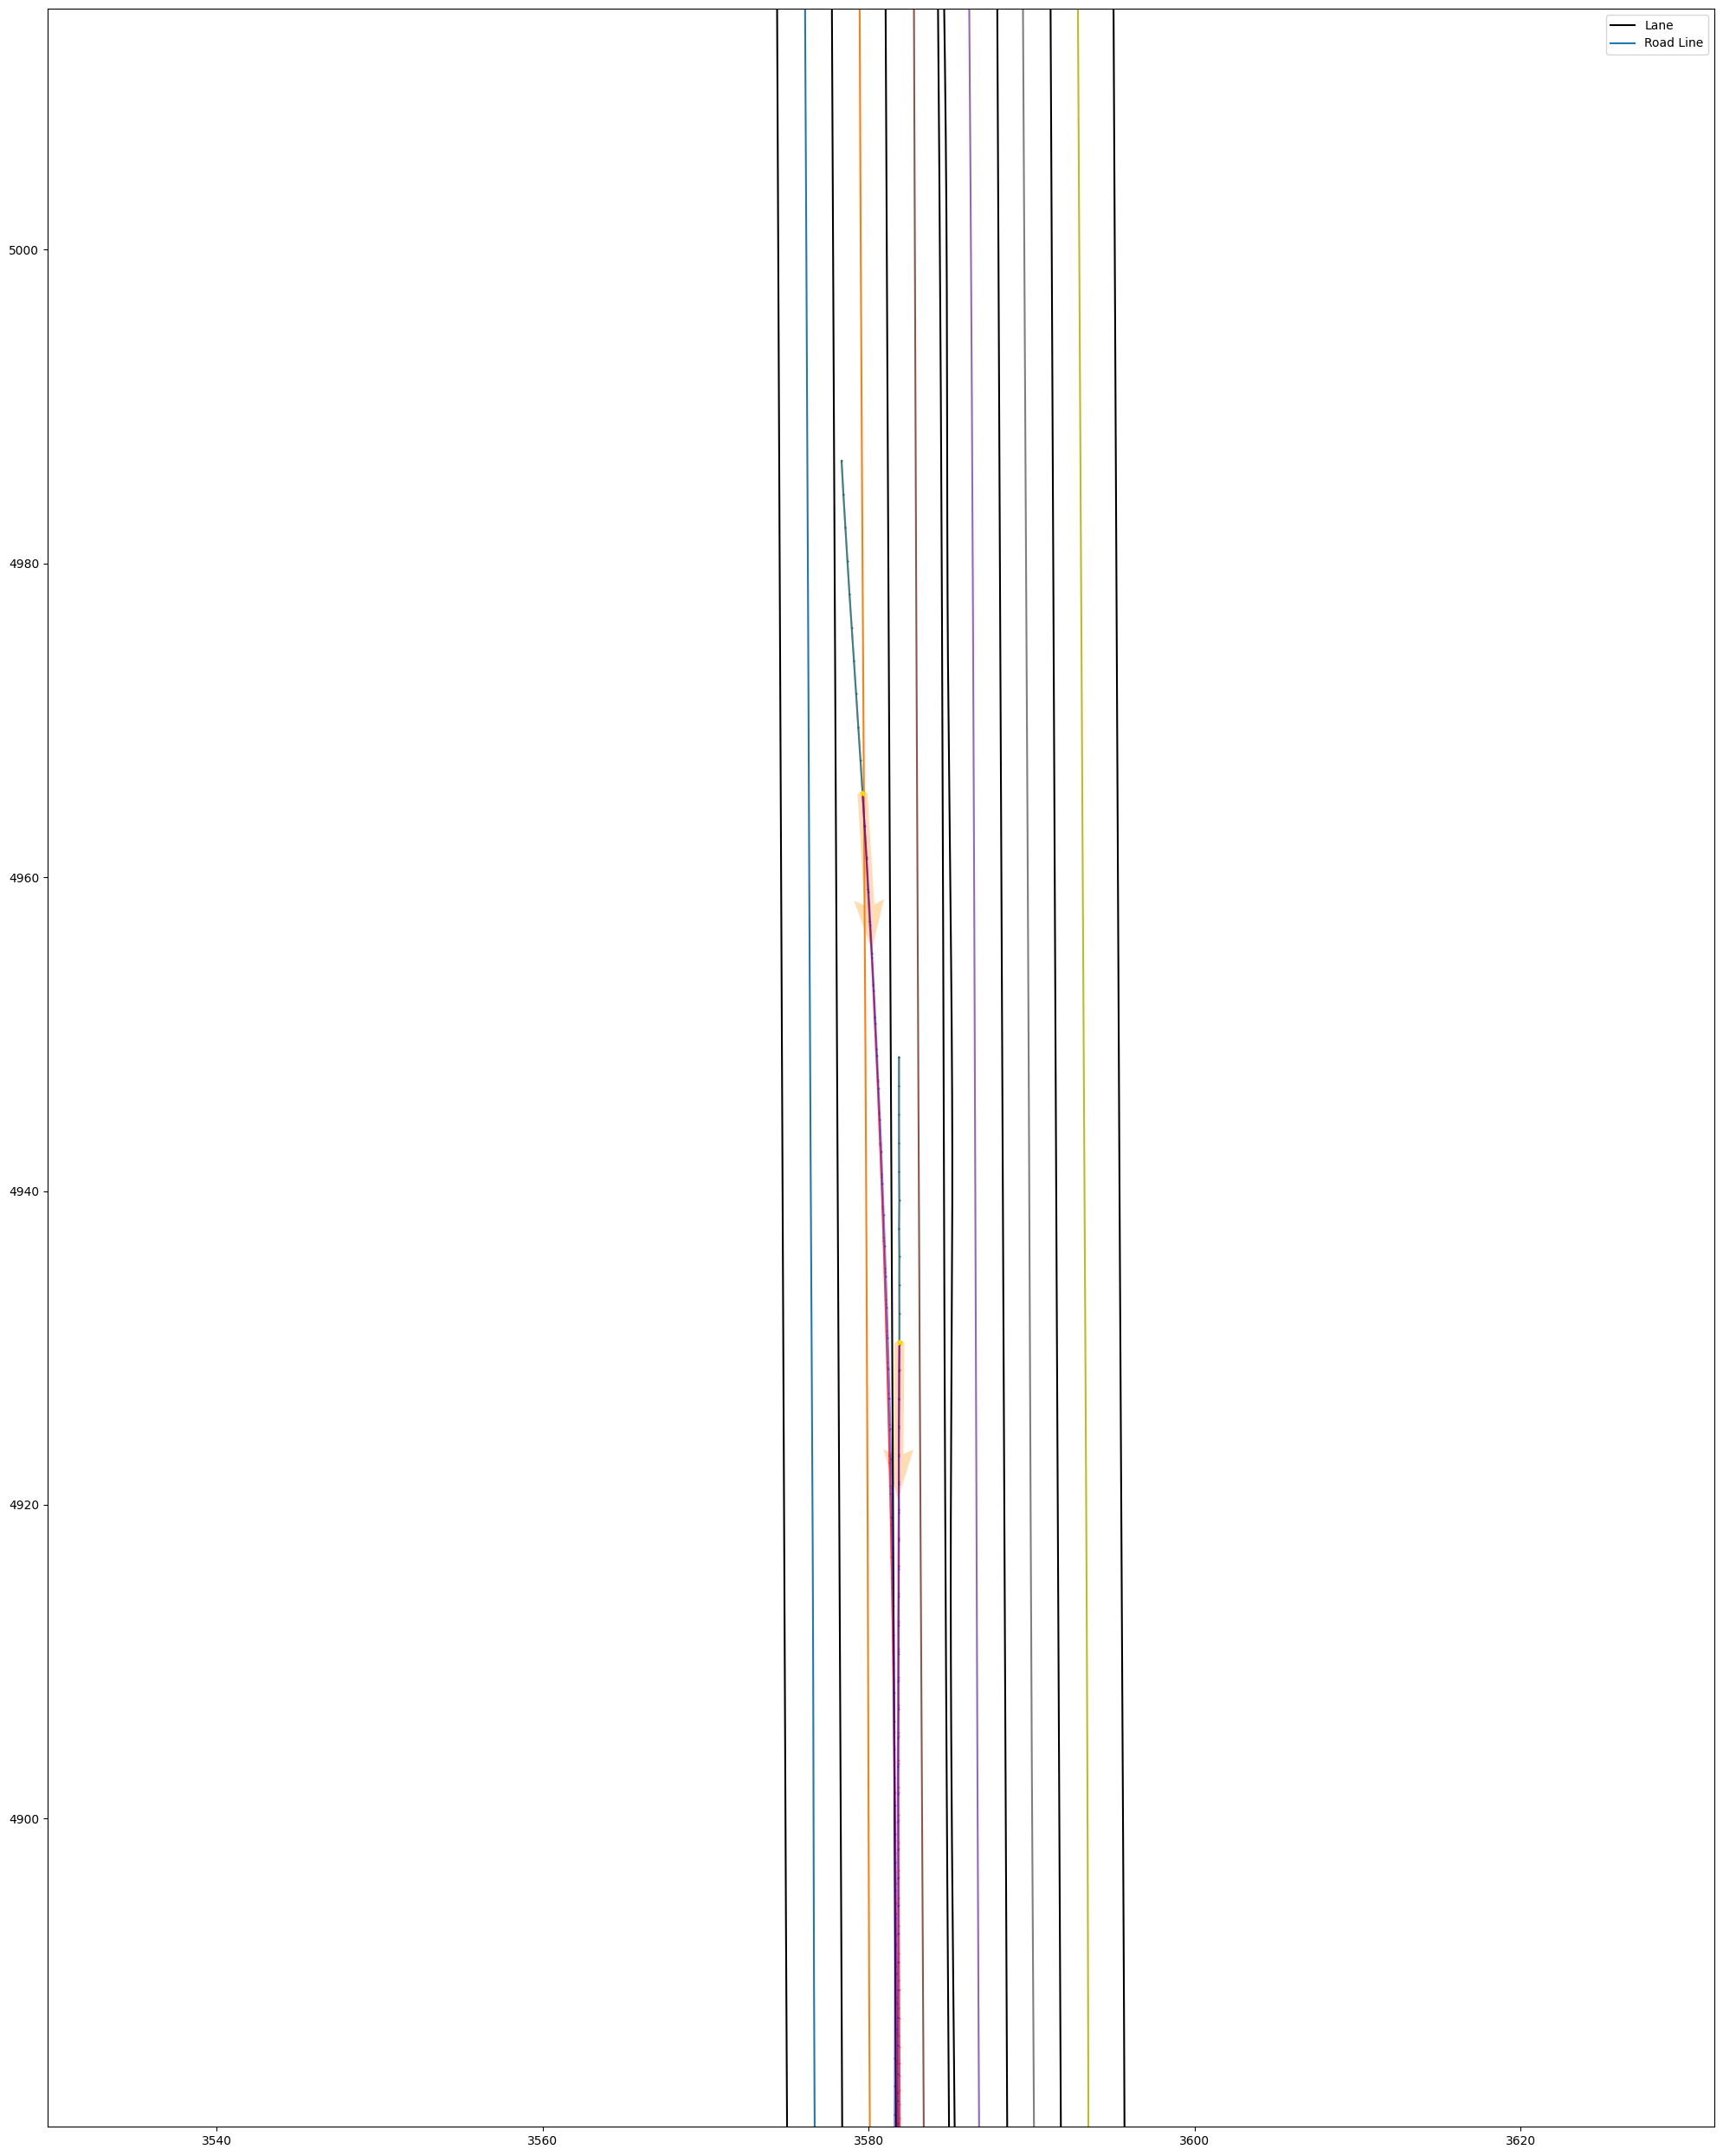

Scenario:0, Scenario ID:b85e1bd6cc8e74c0, Number of Agents:2


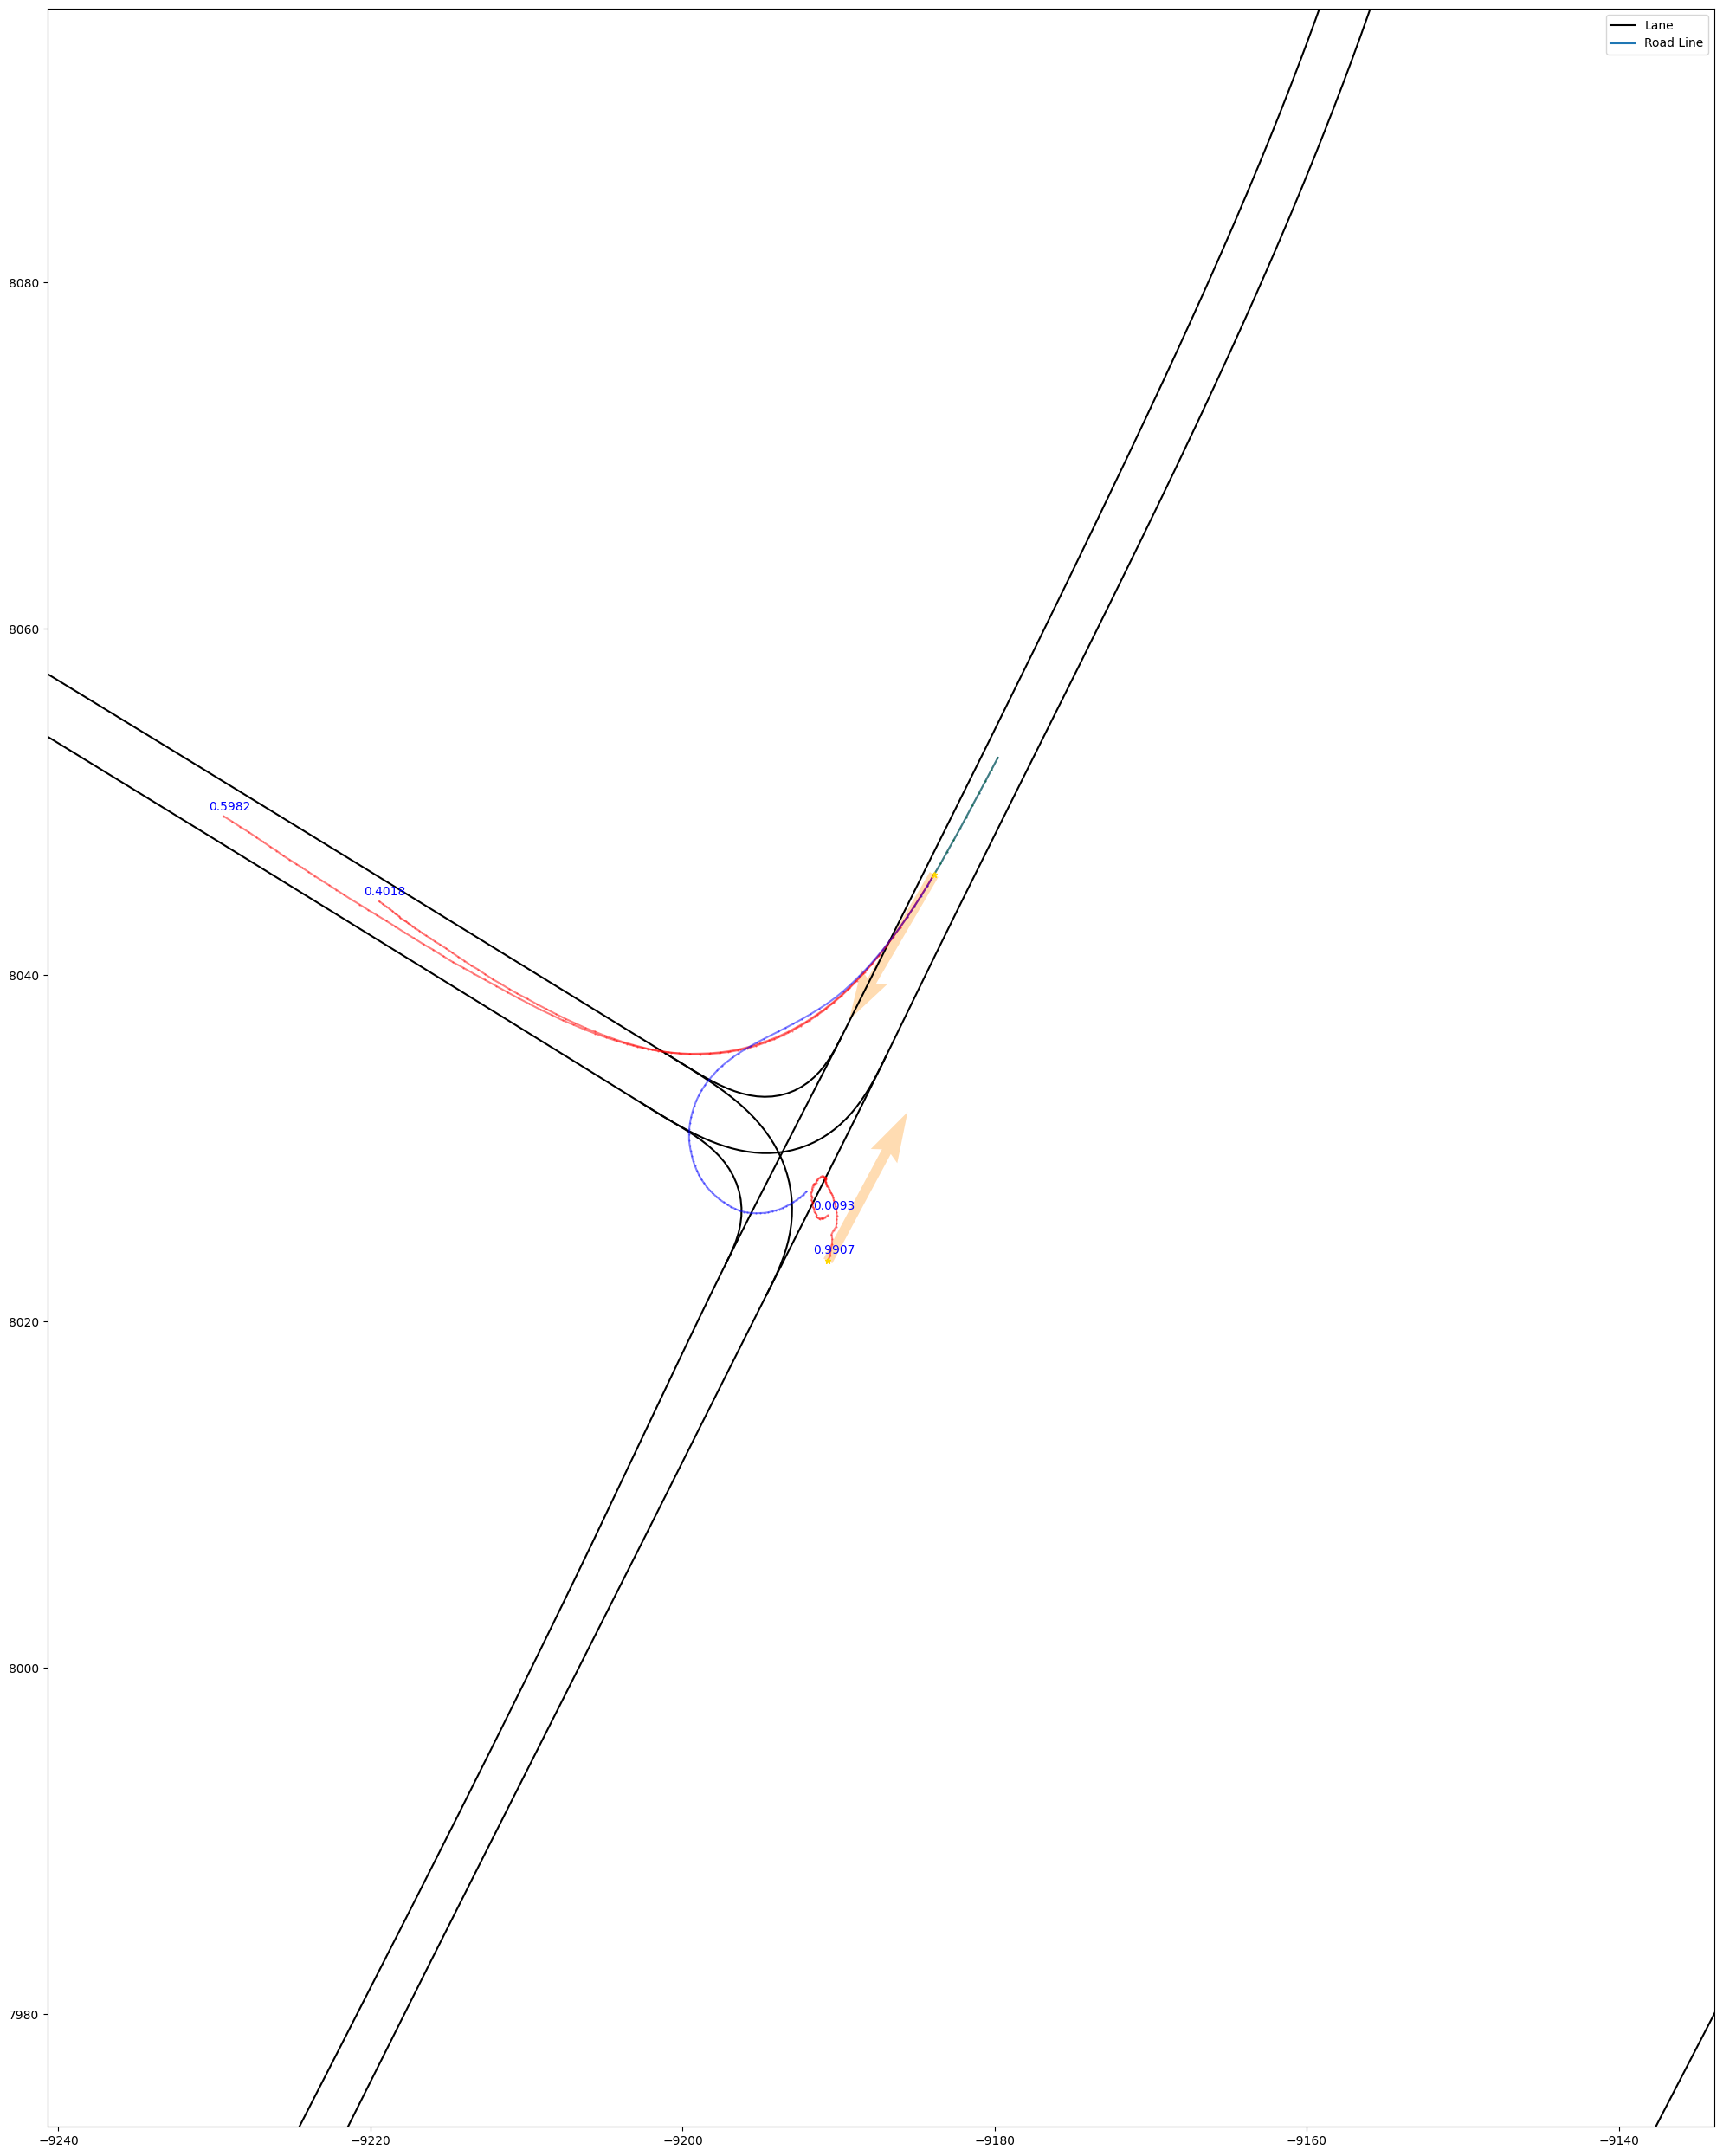

Scenario:1, Scenario ID:4d82fec943ddaa44, Number of Agents:2


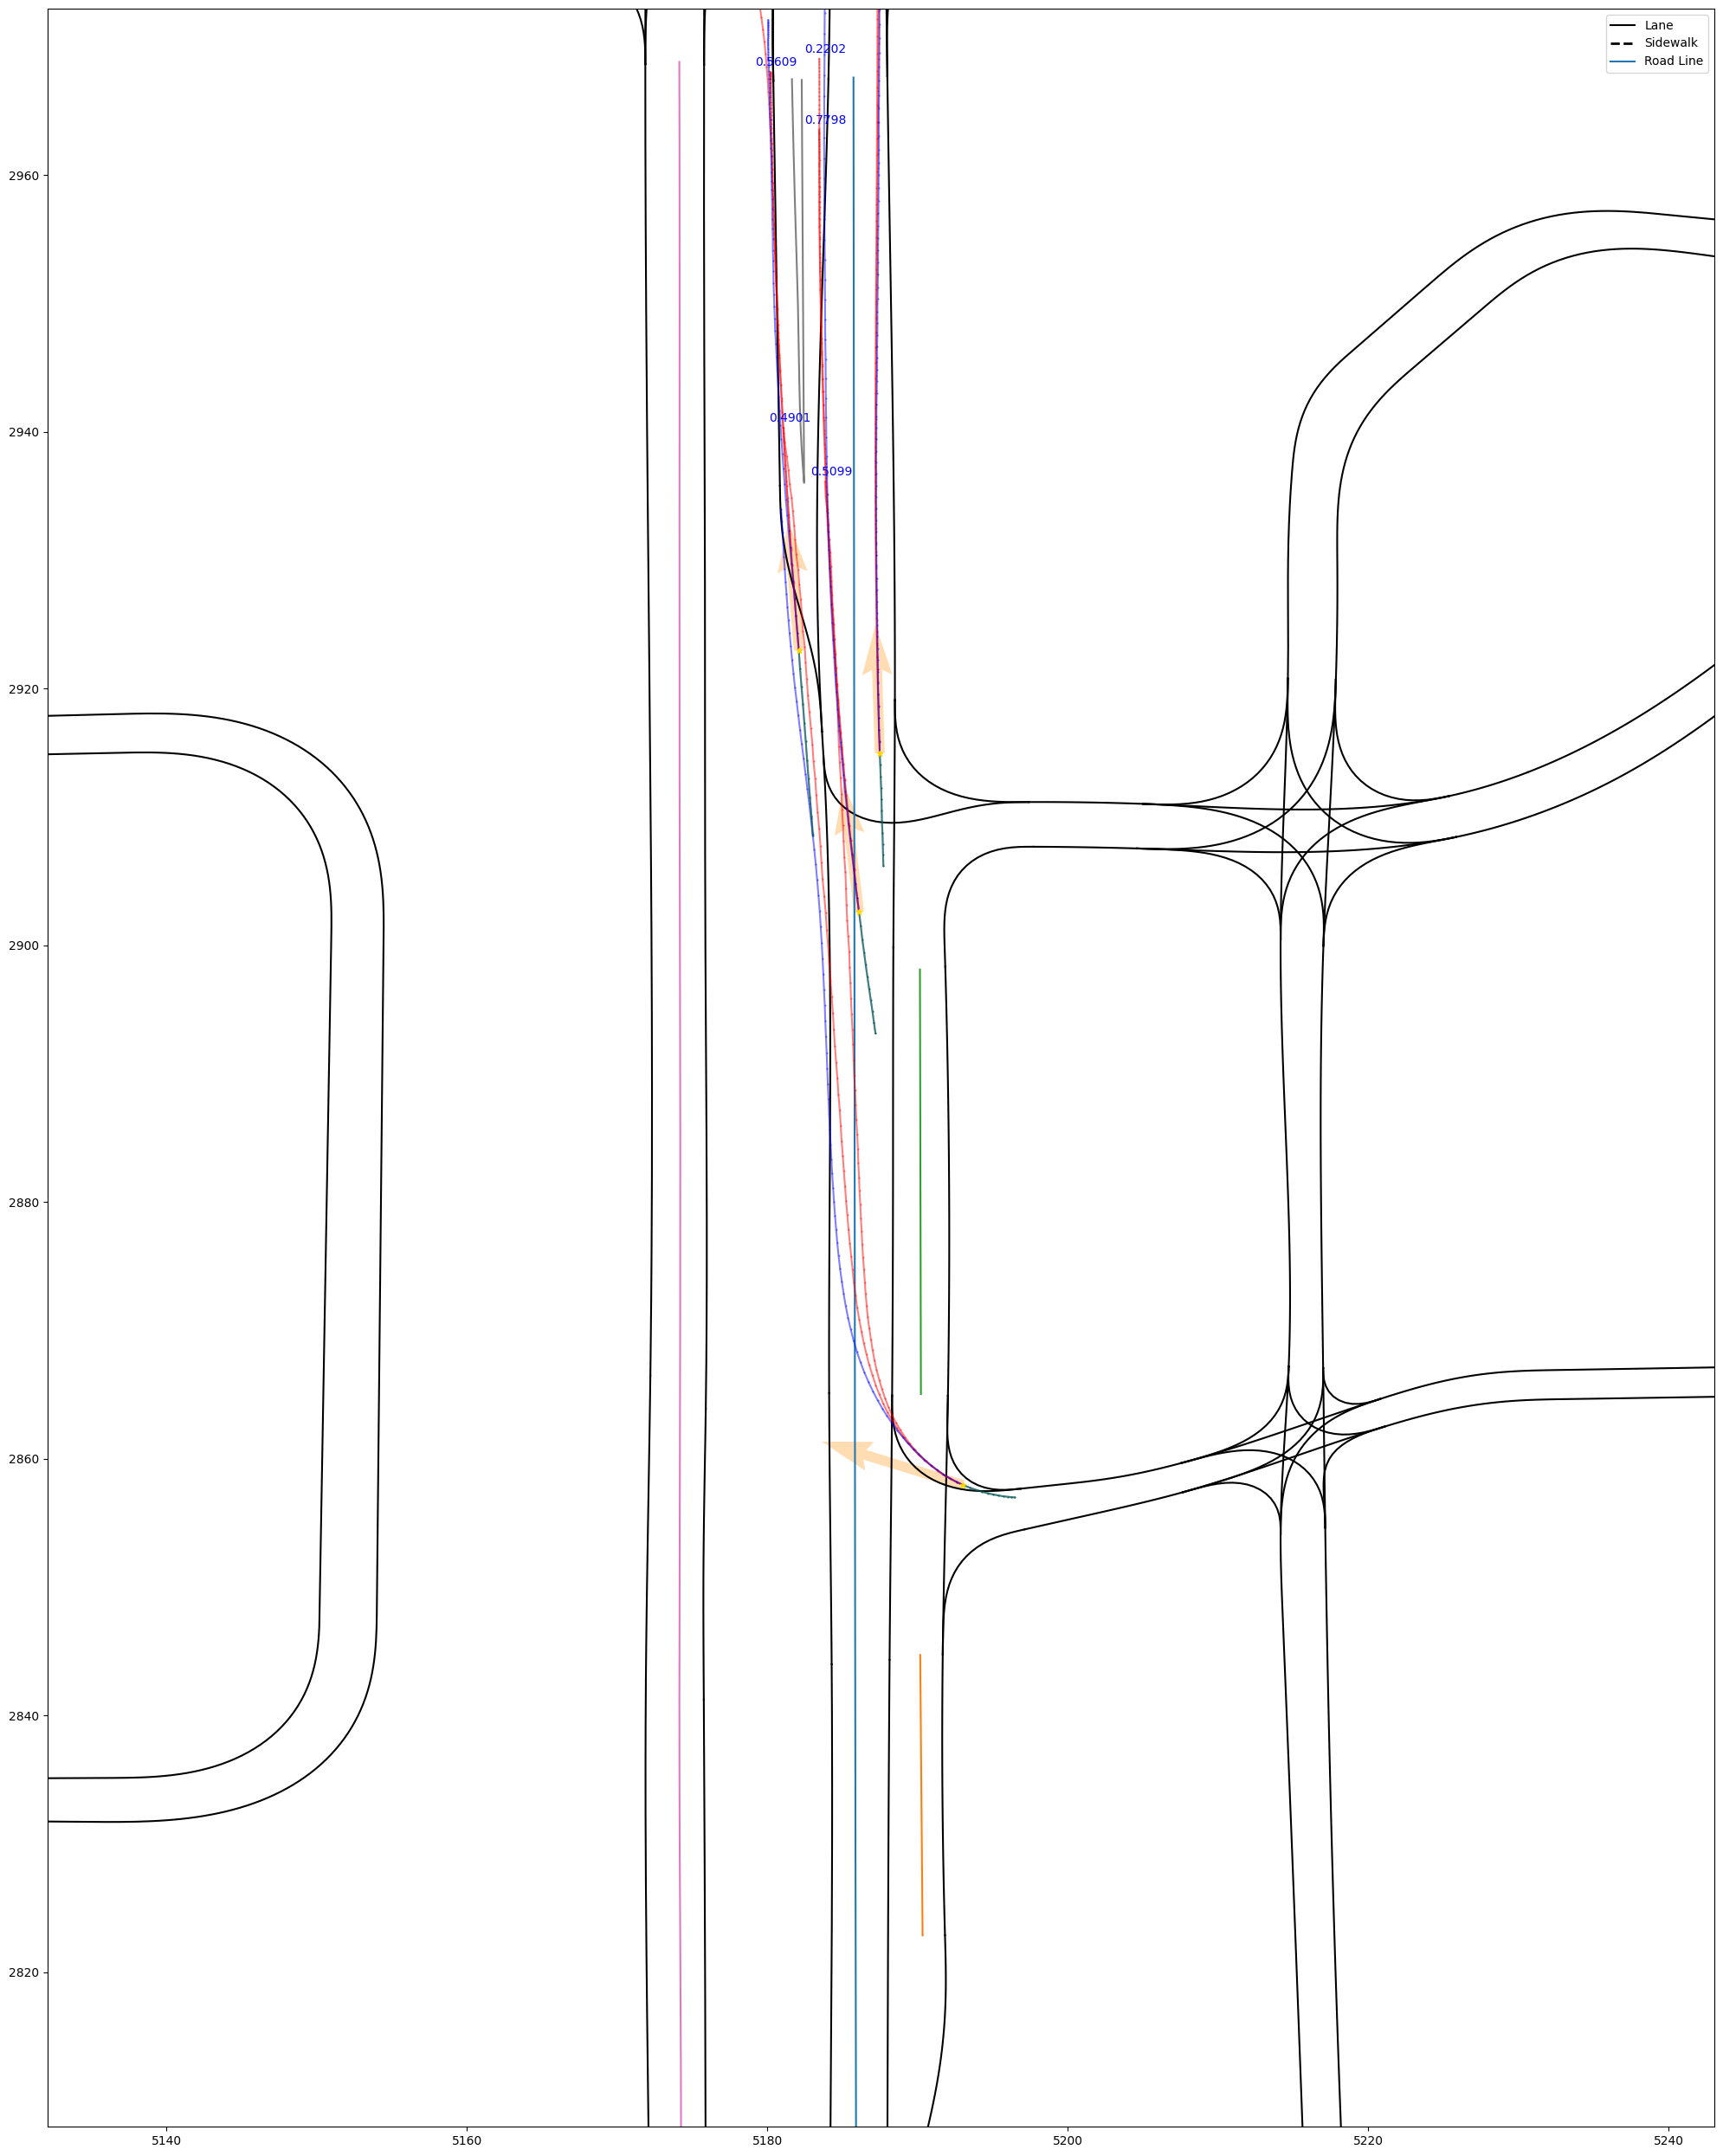

Scenario:2, Scenario ID:bbc29ed5e271f29b, Number of Agents:4


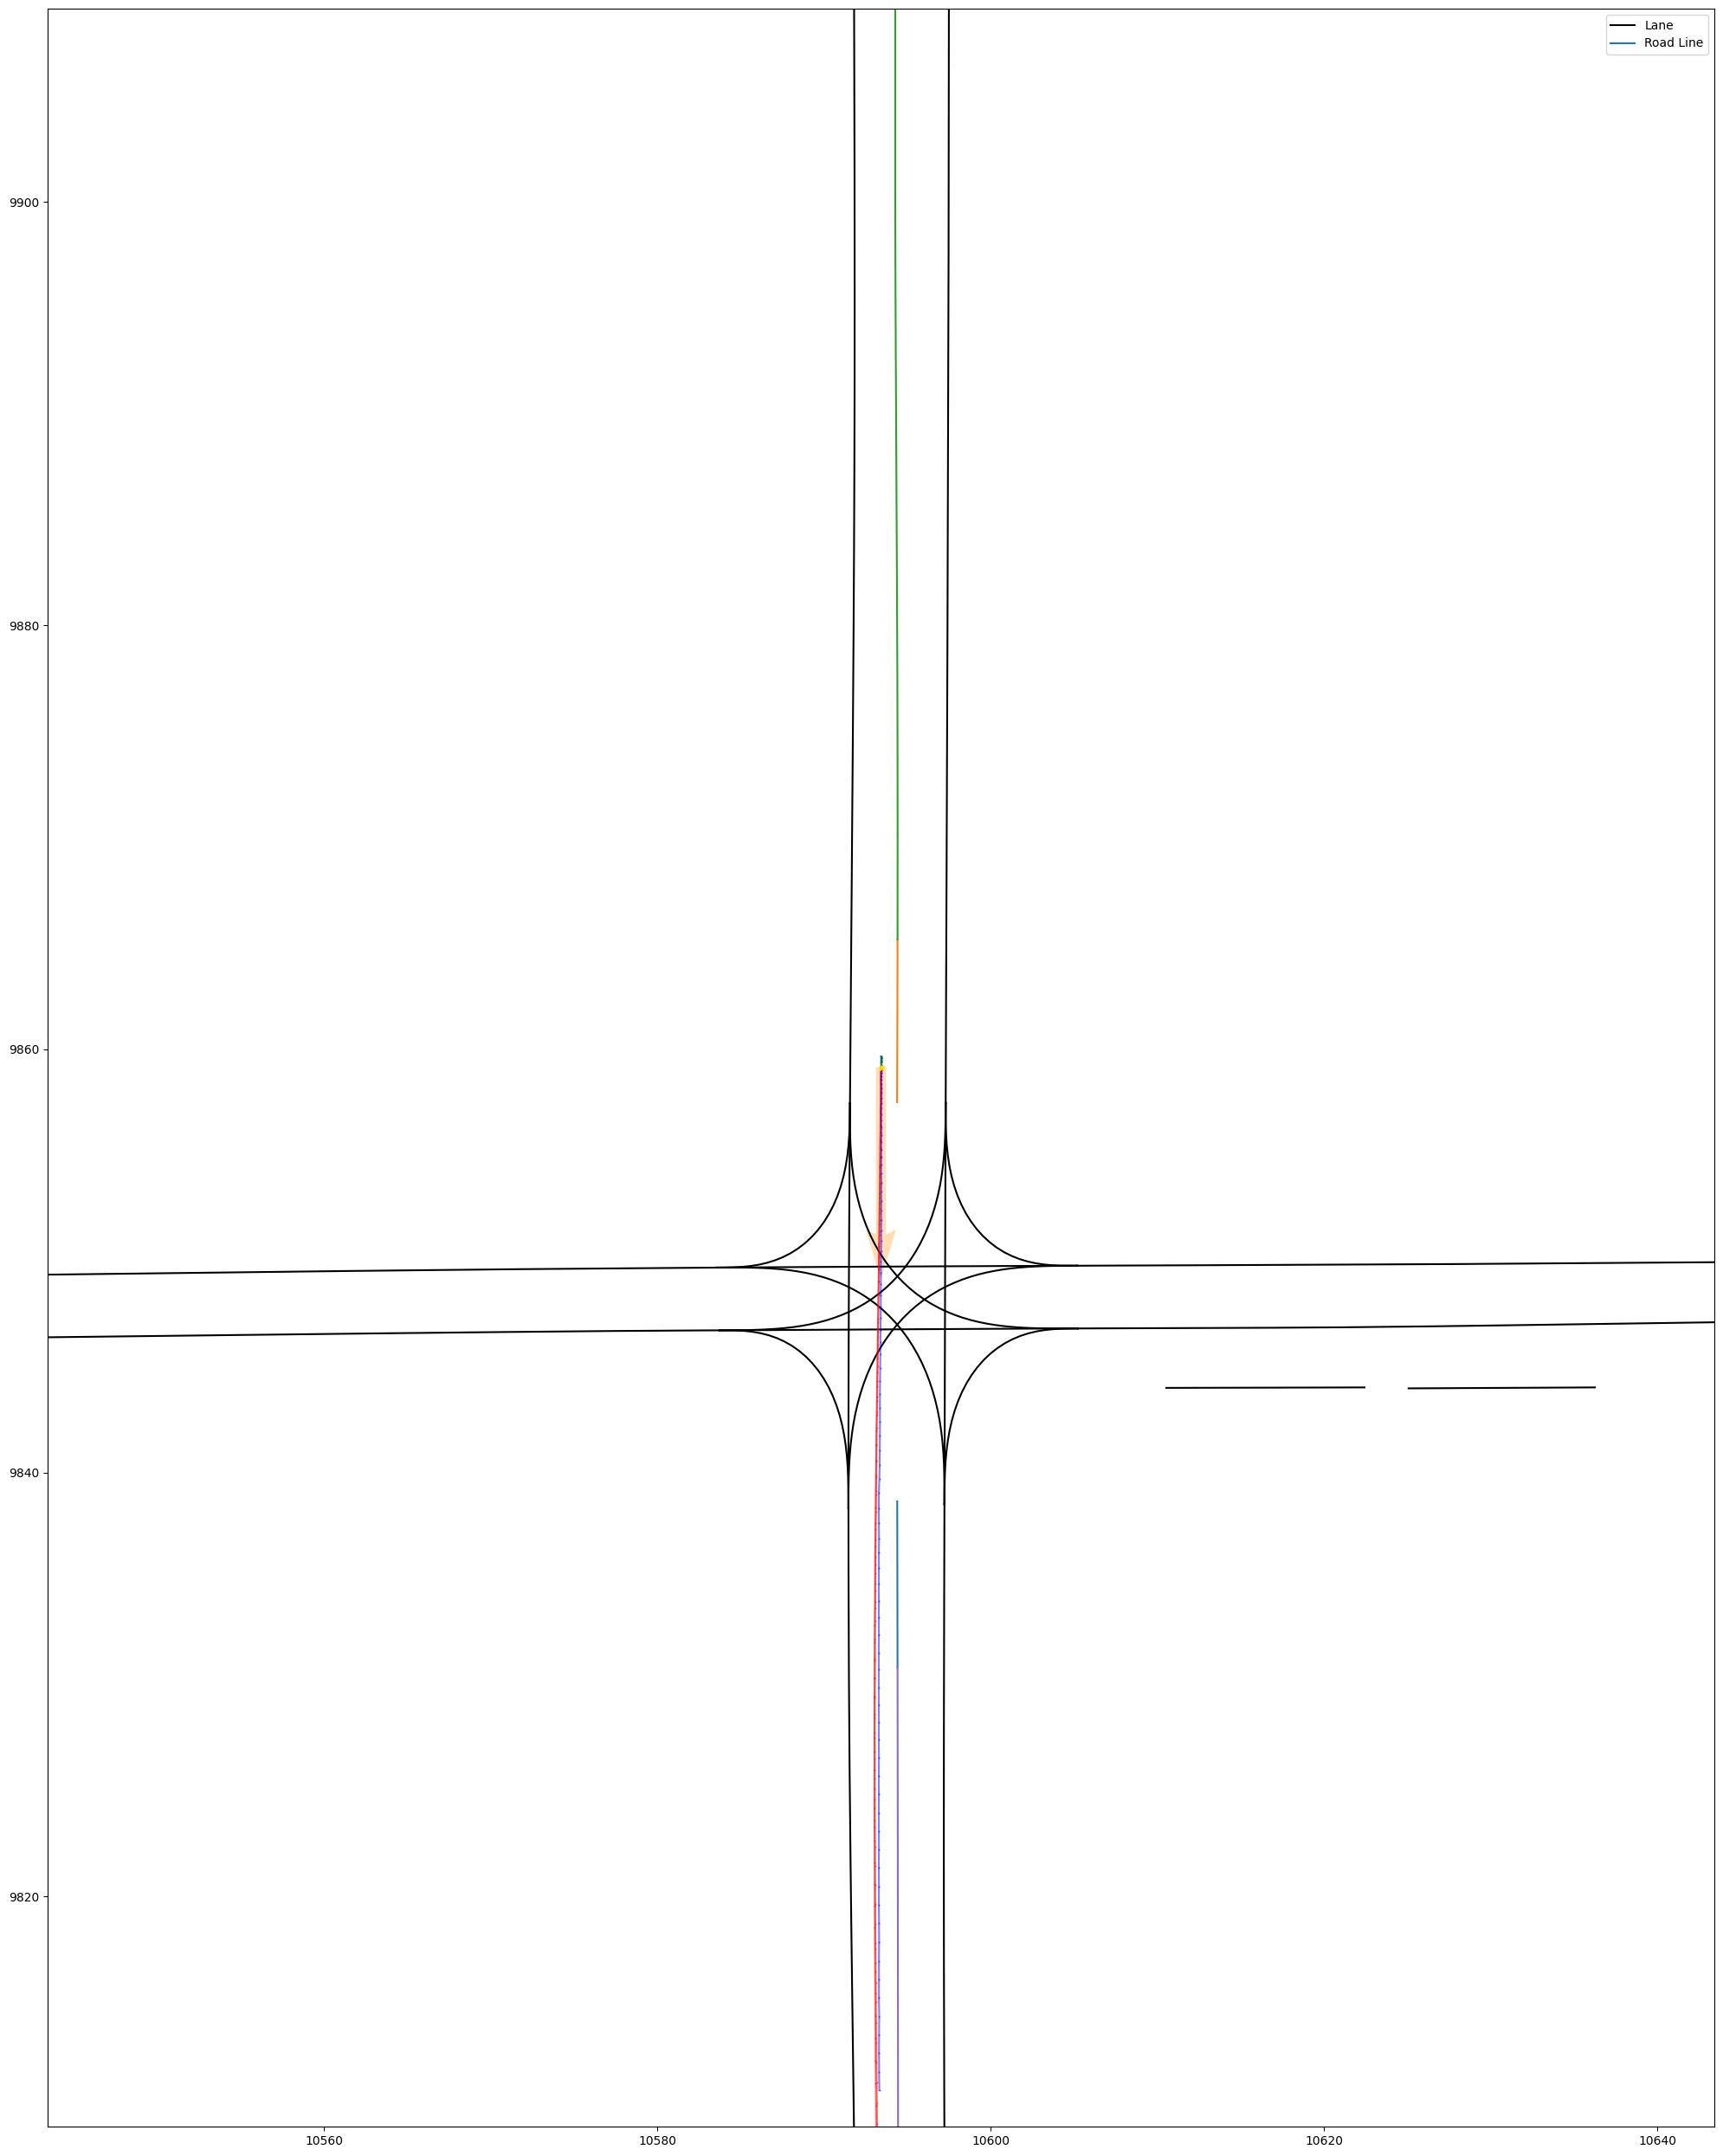

Scenario:3, Scenario ID:e62aa413f7123df2, Number of Agents:1


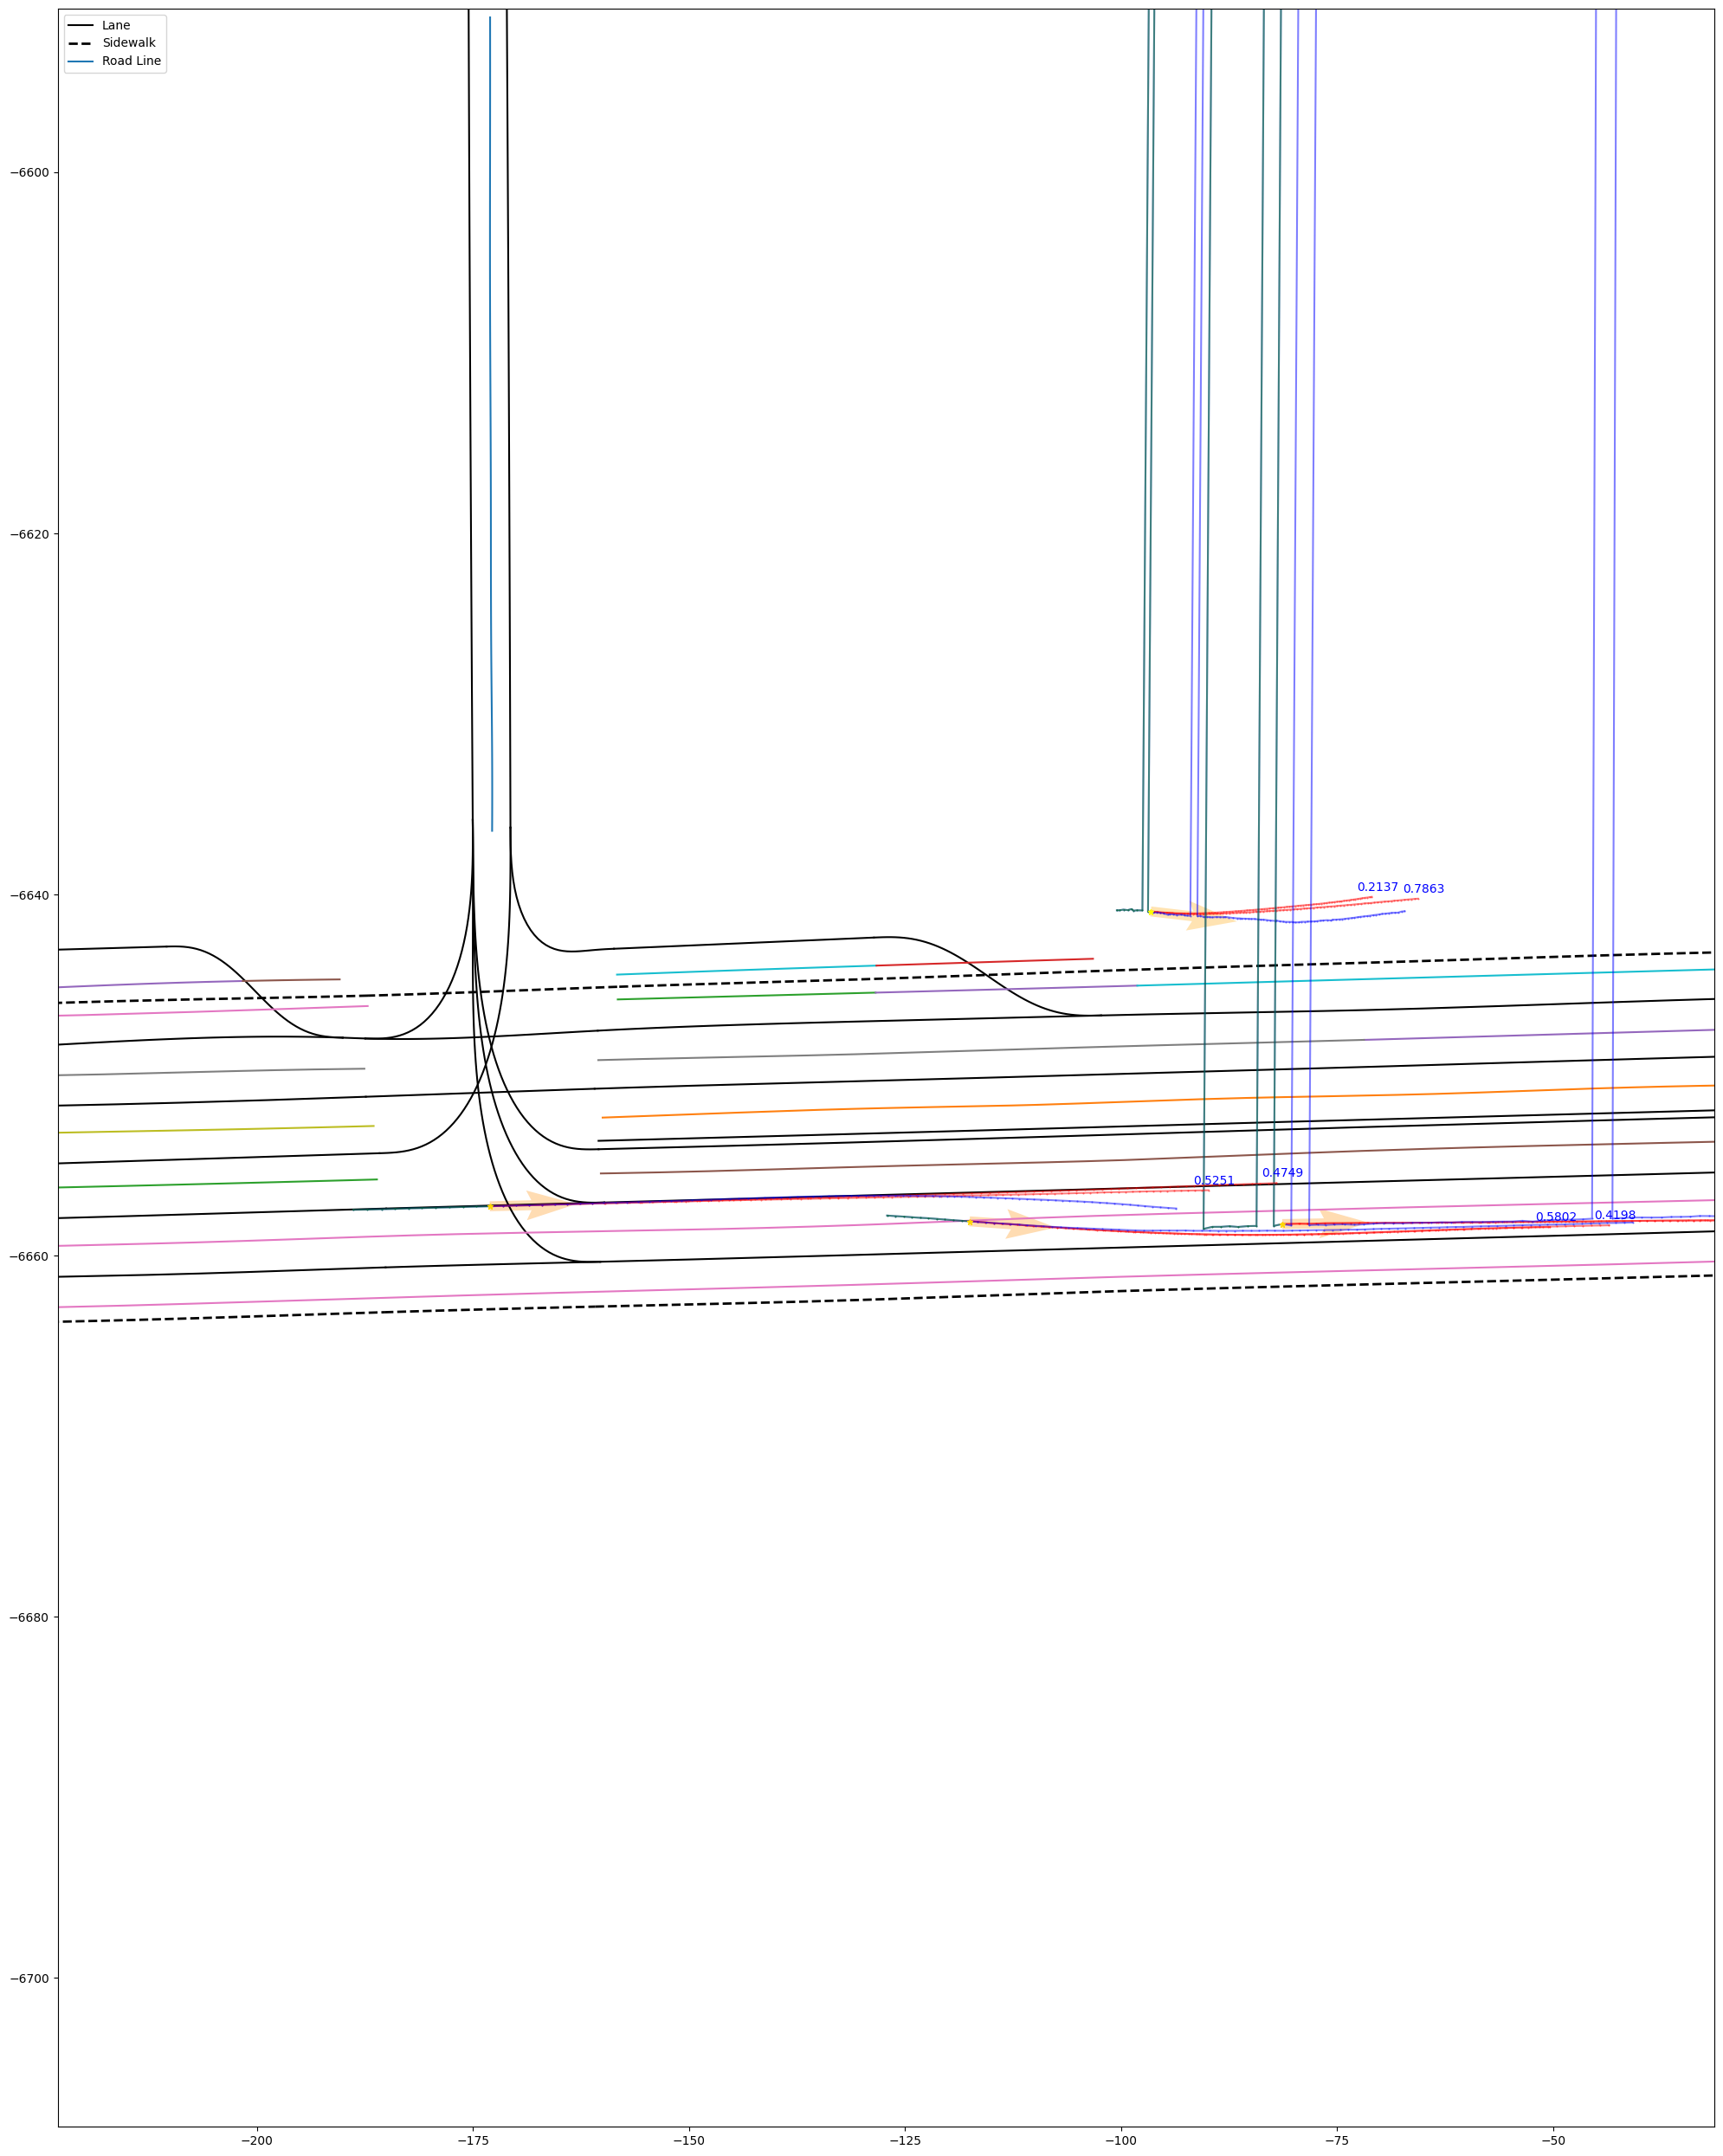

Scenario:4, Scenario ID:75ae707721eb23b4, Number of Agents:4


In [ ]:
# plot all agents (TYPE_VEHICLE, TYPE_PEDESTRIAN, TYPE_CYCLIST) on the same map for a given scenario instead of just one type of agent at a time
# plot VEHICLE traj output
cfg_file_path = '/data/robert/CP-X-Prediction/Intersection-Code/Intersection_Safety_Challenge_Prediction-MTR/Prediction/MTR/tools/cfgs/challenge/mtr-testing-CPX-Prediction.yaml'
testing_set = get_testing_set(cfg_file=cfg_file_path)

k = 0
mode = 2 # only plot the top 3 trajectories
for i in range(len(test_results)):
    scenario_id = str(test_results[i][0]['scenario_id'])
    raw_map_data = testing_set.get_map_data_by_id(scenario_id)
    vector_map = create_map_object(raw_map_data)
    if vector_map is not None:
        plot_traj_withmap_withheading_specific(i,test_results, vector_map, mode)
        print(f'Scenario:{i}, Scenario ID:{scenario_id}, Number of Agents:{len(test_results[i])}')
    k+=1
    if k >= 5:
        break

In [ ]:
# # plot VEHICLE traj output
# k = 0
# for i in range(len(test_results)):
#     for j in range(len(test_results[i])):
#         if test_results[i][j]['object_type'] == 'TYPE_VEHICLE':
#             scenario_id = str(test_results[i][j]['scenario_id'])
#             vector_map = vector_map_dict[scenario_id]
#             if vector_map is not None:
#                 plot_traj_withmap_withheading(i,j, test_results,vector_map,6)
#                 print('----------------------------------------------------')
#                 k += 1
#     if k >= 10:
#         break

In [ ]:

# # plot PEDESTRIAN traj output
# k = 0
# for i in range(len(test_results)):
#     for j in range(len(test_results[i])):
#         if test_results[i][j]['object_type'] == 'TYPE_PEDESTRIAN':
#             scenario_id = str(test_results[i][j]['scenario_id'])
#             vector_map = vector_map_dict[scenario_id]
#             if vector-_map is not None:
#                 plot_traj_withmap_withheading(i,j, test_results,vector_map,6)
#                 print('----------------------------------------------------')
#                 k += 1
#     if k >= 10:
#         break

In [ ]:

# # plot CYCLIST traj output
# k = 0
# for i in range(len(test_results)):
#     for j in range(len(test_results[i])):
#         if test_results[i][j]['object_type'] == 'TYPE_CYCLIST':
#             scenario_id = str(test_results[i][j]['scenario_id'])
#             vector_map = vector_map_dict[scenario_id]
#             if vector_map is not None:
#                 plot_traj_withmap_withheading(i,j, test_results,vector_map,6)
#                 print('----------------------------------------------------')
#                 k += 1
#     if k >= 10:
#         break